# Face Analysis System (Age, Gender, Emotion)

This notebook is a complete Computer Vision project for **face analysis** with three outputs:
- Age group (`0-9 ... 70+`)
- Gender (`male/female`)
- Emotion (`angry, disgust, fear, happy, sad, surprise, neutral`)

## 0. Project Overview

### Design decisions
- **Only one pretrained component**: MediaPipe Face Detector.
- Task models are trained **from scratch** in TensorFlow/Keras.
- Two modes are supported:
  - `train`: train and save new models.
  - `quick-infer`: skip training and load saved `.keras` checkpoints.
  


## 1. Environment Setup

This section installs dependencies, sets random seeds, and checks runtime hardware.

In [1]:
# Core dependencies for Colab
%pip -q install kaggle mediapipe opencv-python-headless seaborn scikit-learn pandas numpy pillow matplotlib tensorboard

import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('OpenCV:', cv2.__version__)
print('NumPy:', np.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

Note: you may need to restart the kernel to use updated packages.
TensorFlow: 2.21.0
OpenCV: 4.13.0
NumPy: 2.4.3
GPU devices: []


In [2]:
import sys
from pathlib import Path


RUN_MODE = 'train'

IS_COLAB = 'google.colab' in sys.modules
PROJECT_ROOT = Path('/content') if IS_COLAB else Path.cwd()
DATA_ROOT = PROJECT_ROOT / 'data'
SRC_ROOT = PROJECT_ROOT / 'src'

ARTIFACT_ROOT = Path('/content/drive/MyDrive/face_analysis_artifacts') if IS_COLAB else (PROJECT_ROOT / 'artifacts')
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints'


LOCAL_UTKFACE_CANDIDATES = [
    DATA_ROOT / 'UTKFace',
    DATA_ROOT / 'utkface',
    DATA_ROOT / 'utkface_raw',
]
LOCAL_FER_CSV_CANDIDATES = [
    DATA_ROOT / 'fer2013.csv',
    DATA_ROOT / 'fer2013' / 'fer2013.csv',
]


USE_KAGGLE_DOWNLOAD = False

print('RUN_MODE:', RUN_MODE)
print('IS_COLAB:', IS_COLAB)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('ARTIFACT_ROOT:', ARTIFACT_ROOT)

RUN_MODE: train
IS_COLAB: False
PROJECT_ROOT: c:\Users\Sarah\Desktop\projects\facerecogn
DATA_ROOT: c:\Users\Sarah\Desktop\projects\facerecogn\data
ARTIFACT_ROOT: c:\Users\Sarah\Desktop\projects\facerecogn\artifacts


## 2. Kaggle + Google Drive Setup

- Drive is used for persistent checkpoints and logs.
- Kaggle API is used to download datasets (`UTKFace`, `FER2013`).

In [3]:
# Runtime-specific storage setup
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    print('Google Drive mounted for artifacts.')
else:
    print('Local runtime detected -> using local artifacts folder.')

print('Kaggle setup disabled in this local-first notebook.')

Local runtime detected -> using local artifacts folder.
Kaggle setup disabled in this local-first notebook.


## 3. Dataset Download (Kaggle API)

Fallback slug lists are used in case a dataset owner/slug changes.

In [4]:
import os
import re

DATA_ROOT.mkdir(parents=True, exist_ok=True)

if RUN_MODE != 'train':
    UTKFACE_ROOT = None
    FER_CSV_PATH = None
    print('RUN_MODE=quick-infer -> skipping dataset discovery.')
else:
    _IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.chip'}
    _UTKFACE_NAME_RE = re.compile(r'^(\d{1,3})_([01])_(\d)_.+')


    def find_utkface_root(search_root: Path) -> Path:
        if not search_root.exists():
            raise FileNotFoundError(f'UTKFace search root does not exist: {search_root}')

        matched = []
        for p in search_root.rglob('*'):
            if p.is_file() and p.suffix.lower() in _IMAGE_SUFFIXES and _UTKFACE_NAME_RE.match(p.name):
                matched.append(p)

        if not matched:
            raise FileNotFoundError('No UTKFace-style image filenames found.')

        root = Path(os.path.commonpath([str(p.parent) for p in matched]))
        print('UTKFace root selected:', root)
        print('UTKFace matched images:', len(matched))
        return root


    def find_fer_csv(search_root: Path) -> Path:
        if search_root.is_file() and search_root.name.lower() == 'fer2013.csv':
            return search_root

        if not search_root.exists():
            raise FileNotFoundError(f'FER search root does not exist: {search_root}')

        candidates = [p for p in search_root.rglob('fer2013.csv') if p.is_file()]
        if not candidates:
            raise FileNotFoundError('fer2013.csv not found')

        best = max(candidates, key=lambda p: p.stat().st_size)
        print('FER CSV selected:', best, 'size:', best.stat().st_size)
        return best


    local_utk_root = next((p for p in LOCAL_UTKFACE_CANDIDATES if p.exists()), DATA_ROOT)
    UTKFACE_ROOT = find_utkface_root(local_utk_root)

    local_fer_file = next((p for p in LOCAL_FER_CSV_CANDIDATES if p.is_file()), None)
    if local_fer_file is not None:
        FER_CSV_PATH = local_fer_file
        print('FER CSV selected:', FER_CSV_PATH)
    else:
        FER_CSV_PATH = find_fer_csv(DATA_ROOT)

    print('Using local dataset paths.')
    print('UTKFACE_ROOT:', UTKFACE_ROOT)
    print('FER_CSV_PATH:', FER_CSV_PATH)

UTKFace root selected: c:\Users\Sarah\Desktop\projects\facerecogn\data\UTKFace
UTKFace matched images: 23705
FER CSV selected: c:\Users\Sarah\Desktop\projects\facerecogn\data\fer2013.csv
Using local dataset paths.
UTKFACE_ROOT: c:\Users\Sarah\Desktop\projects\facerecogn\data\UTKFace
FER_CSV_PATH: c:\Users\Sarah\Desktop\projects\facerecogn\data\fer2013.csv


## 4. Data Cleaning and Label Engineering

We use `src/data_pipeline.py` to:
- parse UTKFace file names,
- map ages into 8 bins,
- validate images,
- split FER2013 into train/val/test,
- build clean DataFrames before tf.data conversion.

In [5]:
# Ensure src/ exists. If a project zip is present, extract it automatically.
if not Path('src').exists() and Path('face_analysis_project.zip').exists():
    import zipfile

    with zipfile.ZipFile('face_analysis_project.zip', 'r') as zf:
        zf.extractall('.')

if not Path('src').exists():
    raise FileNotFoundError('src/ folder not found. Upload or extract project files first.')

from src.config import AGE_BINS, AGE_GROUP_LABELS, EMOTION_LABELS, GENDER_LABELS, TrainConfig
from src.data_pipeline import (
    build_age_gender_datasets,
    build_emotion_datasets,
    load_fer2013_dataframe,
    load_utkface_dataframe,
)

utk_df = None
fer_train_df = None
fer_val_df = None
fer_test_df = None

if RUN_MODE == 'train':
    utk_df = load_utkface_dataframe(str(UTKFACE_ROOT), age_bins=AGE_BINS)
    fer_train_df, fer_val_df, fer_test_df = load_fer2013_dataframe(str(FER_CSV_PATH))

    print('UTKFace samples:', len(utk_df))
    print('FER train/val/test:', len(fer_train_df), len(fer_val_df), len(fer_test_df))
    utk_df.head()
else:
    print('RUN_MODE=quick-infer -> skipping dataset loading and training-only steps.')

UTKFace samples: 23705
FER train/val/test: 28709 3589 3589


## 5. Exploratory Data Analysis (EDA)

Here we inspect class distributions and sample faces/emotions.

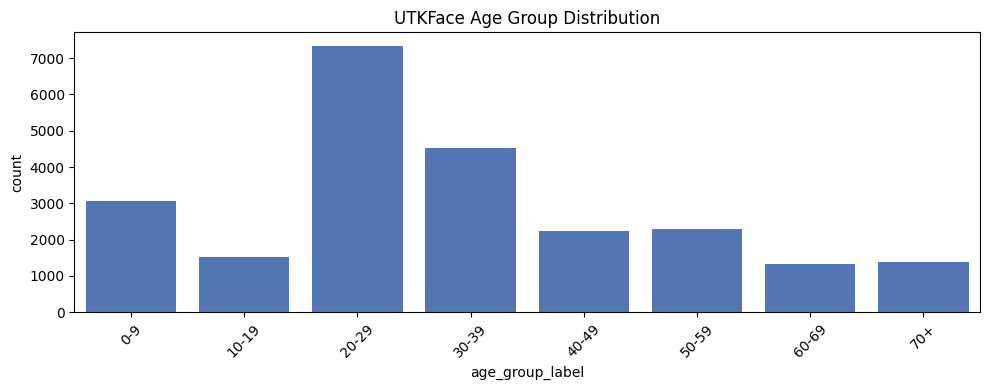

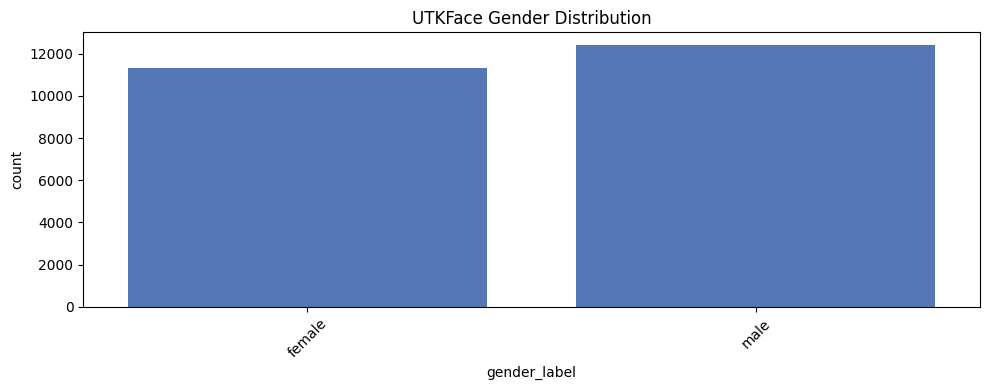

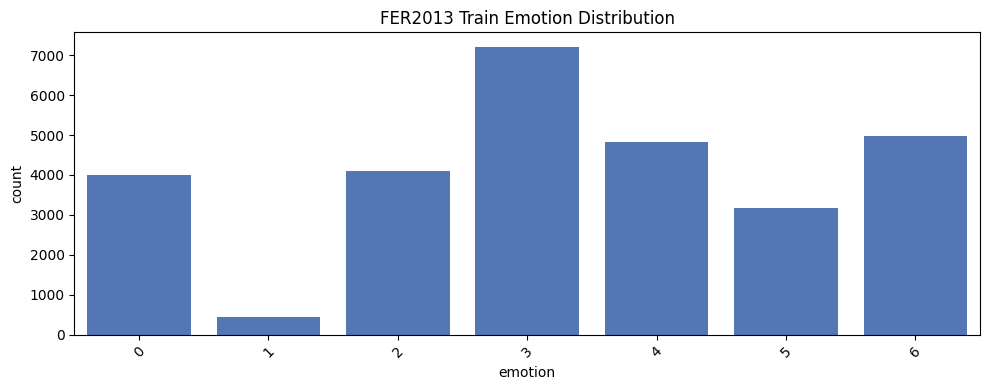

In [6]:
from src.visualize import plot_label_distribution, show_image_grid

if RUN_MODE != 'train':
    print('Skipped label distribution plots in quick-infer mode.')
else:
    plot_label_distribution(utk_df, 'age_group_label', 'UTKFace Age Group Distribution')
    plot_label_distribution(utk_df, 'gender_label', 'UTKFace Gender Distribution')
    plot_label_distribution(fer_train_df, 'emotion', 'FER2013 Train Emotion Distribution')

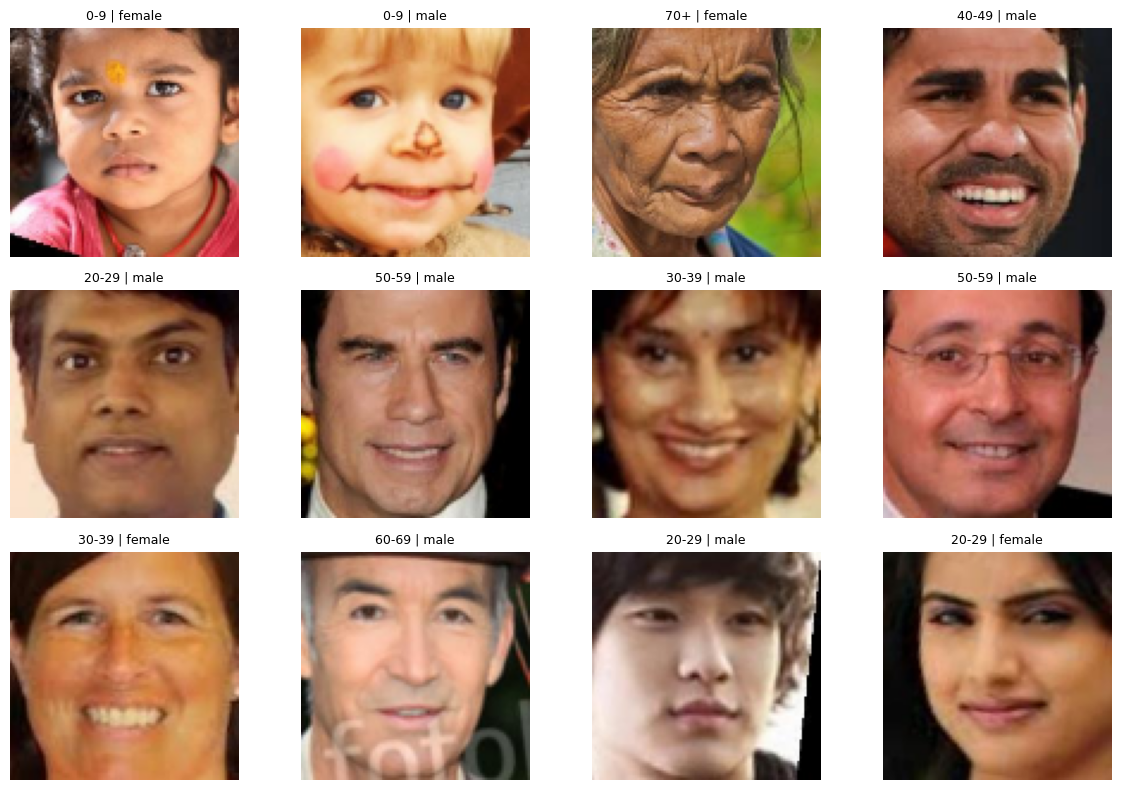

In [7]:
# Show random UTKFace examples with labels
if RUN_MODE != 'train':
    print('Skipped UTKFace sample grid in quick-infer mode.')
else:
    sample_rows = utk_df.sample(n=min(12, len(utk_df)), random_state=SEED)
    images = []
    titles = []
    for _, row in sample_rows.iterrows():
        img = cv2.imread(row['path'])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (96, 96))
        images.append(img)
        titles.append(f"{row['age_group_label']} | {row['gender_label']}")

    show_image_grid(np.array(images), titles=titles, ncols=4, figsize=(12, 8))

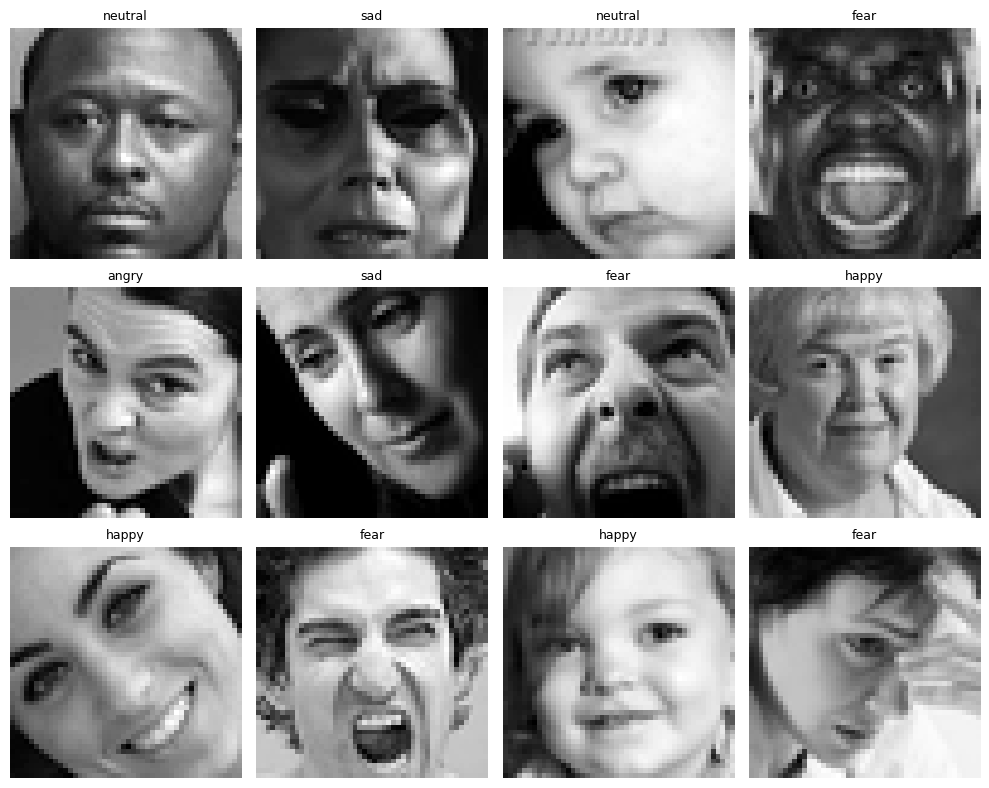

In [8]:
# Show random FER examples
if RUN_MODE != 'train':
    print('Skipped FER sample grid in quick-infer mode.')
else:
    def fer_pixels_to_img(pixel_str: str):
        arr = np.fromstring(pixel_str, sep=' ', dtype=np.uint8)
        if arr.size != 48 * 48:
            return None
        return arr.reshape(48, 48)

    fer_sample = fer_train_df.sample(n=min(12, len(fer_train_df)), random_state=SEED)
    emo_images = []
    emo_titles = []
    for _, row in fer_sample.iterrows():
        img = fer_pixels_to_img(row['pixels'])
        if img is None:
            continue
        emo_images.append(img)
        emo_titles.append(EMOTION_LABELS[int(row['emotion'])])

    show_image_grid(np.array(emo_images), titles=emo_titles, ncols=4, figsize=(10, 8))

## 6. Preprocessing Pipelines (`tf.data`)

- Age/Gender input: `128x128 RGB`
- Emotion input: `64x64 grayscale`
- Augmentations: horizontal flip, brightness/contrast jitter

In [9]:
cfg = TrainConfig()

train_ag_ds = None
val_ag_ds = None
test_ag_ds = None
train_emo_ds = None
val_emo_ds = None
test_emo_ds = None

if RUN_MODE == 'train':
    train_ag_ds, val_ag_ds, test_ag_ds = build_age_gender_datasets(utk_df, batch_size=cfg.batch_size)
    train_emo_ds, val_emo_ds, test_emo_ds = build_emotion_datasets(
        train_df=fer_train_df,
        val_df=fer_val_df,
        test_df=fer_test_df,
        batch_size=cfg.batch_size,
    )

    print('Age/Gender dataset objects ready')
    print('Emotion dataset objects ready')

    # Smoke checks for tensor shapes
    x_ag, y_ag = next(iter(train_ag_ds))
    print('AG batch image shape:', x_ag.shape)
    print('AG age labels shape:', y_ag['age_output'].shape)
    print('AG gender labels shape:', y_ag['gender_output'].shape)

    x_em, y_em = next(iter(train_emo_ds))
    print('Emotion batch image shape:', x_em.shape)
    print('Emotion labels shape:', y_em.shape)
else:
    print('RUN_MODE=quick-infer -> skipping dataset pipeline build.')

Age/Gender dataset objects ready
Emotion dataset objects ready
AG batch image shape: (64, 128, 128, 3)
AG age labels shape: (64,)
AG gender labels shape: (64,)
Emotion batch image shape: (64, 64, 64, 1)
Emotion labels shape: (64,)


## 7. Model Definitions

- `build_age_gender_model`: shared CNN backbone + two output heads.
- `build_emotion_model`: CNN classifier for FER emotion labels.

In [10]:
from src.models import build_age_gender_model, build_emotion_model

age_gender_model = build_age_gender_model(input_shape=(128, 128, 3), num_age_classes=len(AGE_GROUP_LABELS))
emotion_model = build_emotion_model(input_shape=(64, 64, 1), num_emotions=len(EMOTION_LABELS))

age_gender_model.summary()
emotion_model.summary()

Model: "age_gender_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,432 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[

 Total params: 1,291,369 (4.93 MB)

 Trainable params: 1,289,449 (4.92 MB)

 Non-trainable params: 1,920 (7.50 KB)

Model: "emotion_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ emotion_input (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 683,303 (2.61 MB)

 Trainable params: 681,895 (2.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 8. Training

Training defaults:
- Optimizer: Adam (`1e-3`)
- ReduceLROnPlateau
- EarlyStopping (`patience=5`)
- Best checkpoints saved as `.keras` in Google Drive

In [11]:
from src.train import train_age_gender, train_emotion
from src.visualize import plot_training_history

AG_BEST_PATH = CHECKPOINT_ROOT / 'age_gender' / 'age_gender_best.keras'
EMO_BEST_PATH = CHECKPOINT_ROOT / 'emotion' / 'emotion_best.keras'
RUN_MODE = "quick_infer"
if RUN_MODE == 'train':
    history_ag = train_age_gender(age_gender_model, train_ag_ds, val_ag_ds, out_dir=str(CHECKPOINT_ROOT))
    history_emo = train_emotion(emotion_model, train_emo_ds, val_emo_ds, out_dir=str(CHECKPOINT_ROOT))

    plot_training_history(history_ag, title='Age+Gender Model')
    plot_training_history(history_emo, title='Emotion Model')

    age_gender_model = tf.keras.models.load_model(AG_BEST_PATH)
    emotion_model = tf.keras.models.load_model(EMO_BEST_PATH)
else:
    if not AG_BEST_PATH.exists() or not EMO_BEST_PATH.exists():
        raise FileNotFoundError('Checkpoints not found. Run with RUN_MODE="train" first.')
    age_gender_model = tf.keras.models.load_model(AG_BEST_PATH)
    emotion_model = tf.keras.models.load_model(EMO_BEST_PATH)

print('Loaded models:')
print(' -', AG_BEST_PATH)
print(' -', EMO_BEST_PATH)

Loaded models:
 - c:\Users\Sarah\Desktop\projects\facerecogn\artifacts\checkpoints\age_gender\age_gender_best.keras
 - c:\Users\Sarah\Desktop\projects\facerecogn\artifacts\checkpoints\emotion\emotion_best.keras


## 9. Evaluation

This section computes:
- Accuracy metrics
- Classification reports
- Confusion matrices
- Threshold checks vs project targets

RUN_MODE: train
Gender accuracy: 0.9159
Age-group accuracy: 0.5920
Emotion accuracy: 0.6077


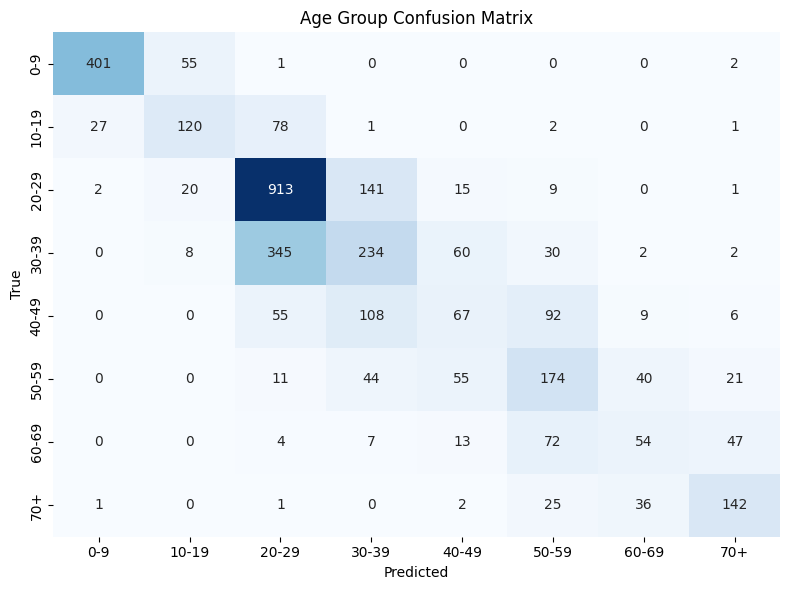

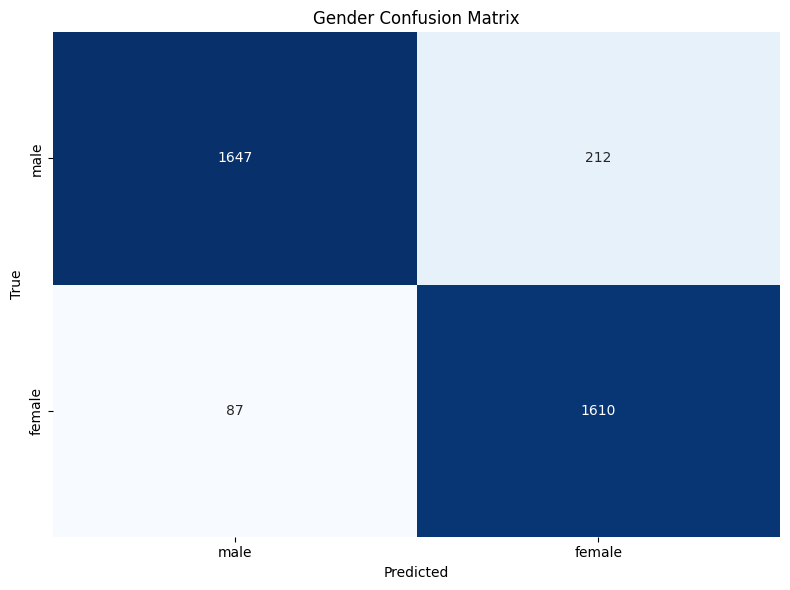

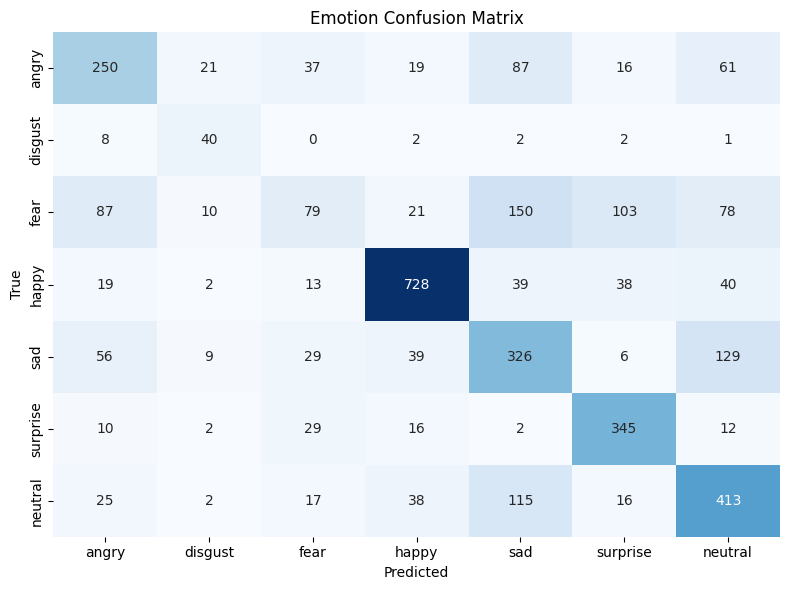

In [12]:
# from src.evaluate import evaluate_age_gender, evaluate_emotion
# from src.visualize import plot_confusion_matrix

# RUN_MODE = "train"
# ag_results = None
# emo_results = None

# if RUN_MODE == 'train':
#     ag_results = evaluate_age_gender(age_gender_model, test_ag_ds, age_group_labels=AGE_GROUP_LABELS)
#     emo_results = evaluate_emotion(emotion_model, test_emo_ds, emotion_labels=EMOTION_LABELS)

#     print(f"Gender accuracy: {ag_results['gender_accuracy']:.4f}")
#     print(f"Age-group accuracy: {ag_results['age_accuracy']:.4f}")
#     print(f"Emotion accuracy: {emo_results['emotion_accuracy']:.4f}")

#     plot_confusion_matrix(ag_results['age_confusion_matrix'], AGE_GROUP_LABELS, 'Age Group Confusion Matrix')
#     plot_confusion_matrix(ag_results['gender_confusion_matrix'], GENDER_LABELS, 'Gender Confusion Matrix')
#     plot_confusion_matrix(emo_results['emotion_confusion_matrix'], EMOTION_LABELS, 'Emotion Confusion Matrix')
# else:
#     print('Skipped evaluation in quick-infer mode.')


from src.evaluate import evaluate_age_gender, evaluate_emotion
from src.visualize import plot_confusion_matrix
RUN_MODE = "train"
print("RUN_MODE:", RUN_MODE)
ag_results = None
emo_results = None

if RUN_MODE != "train" or test_ag_ds is None or test_emo_ds is None:
    print("Skipped evaluation: quick-infer mode (or test datasets are not built).")
else:
    ag_results = evaluate_age_gender(age_gender_model, test_ag_ds, age_group_labels=AGE_GROUP_LABELS)
    emo_results = evaluate_emotion(emotion_model, test_emo_ds, emotion_labels=EMOTION_LABELS)

    print(f"Gender accuracy: {ag_results['gender_accuracy']:.4f}")
    print(f"Age-group accuracy: {ag_results['age_accuracy']:.4f}")
    print(f"Emotion accuracy: {emo_results['emotion_accuracy']:.4f}")

    plot_confusion_matrix(ag_results['age_confusion_matrix'], AGE_GROUP_LABELS, 'Age Group Confusion Matrix')
    plot_confusion_matrix(ag_results['gender_confusion_matrix'], GENDER_LABELS, 'Gender Confusion Matrix')
    plot_confusion_matrix(emo_results['emotion_confusion_matrix'], EMOTION_LABELS, 'Emotion Confusion Matrix')


In [13]:
# Target checks from project plan
TARGETS = {
    'gender_accuracy': 0.90,
    'age_accuracy': 0.55,
    'emotion_accuracy': 0.60,
}

if RUN_MODE != 'train':
    print('Skipped target checks in quick-infer mode.')
else:
    current = {
        'gender_accuracy': ag_results['gender_accuracy'],
        'age_accuracy': ag_results['age_accuracy'],
        'emotion_accuracy': emo_results['emotion_accuracy'],
    }

    for name, threshold in TARGETS.items():
        value = current[name]
        status = 'PASS' if value >= threshold else 'FAIL'
        print(f'{name}: {value:.4f} (target {threshold:.2f}) -> {status}')

gender_accuracy: 0.9159 (target 0.90) -> PASS
age_accuracy: 0.5920 (target 0.55) -> PASS
emotion_accuracy: 0.6077 (target 0.60) -> PASS


## 10. Inference Pipeline

Inference flow:
1. Detect faces with MediaPipe.
2. Crop each face.
3. Predict age-group + gender + emotion.
4. Draw overlays on image/frame.

In [14]:
import importlib
import src.infer as infer
importlib.reload(infer)

from src.infer import annotate_image, detect_faces_bgr, load_detector, predict_face, run_video_inference
detector = load_detector()
print("MediaPipe/OpenCV detector initialized")


MediaPipe/OpenCV detector initialized


In [15]:
from src.infer import annotate_image, detect_faces_bgr, load_detector, predict_face, run_video_inference

detector = load_detector()
print('MediaPipe detector initialized')

MediaPipe detector initialized


## 11. Demo: Image Upload

Upload an image and run full face analysis.

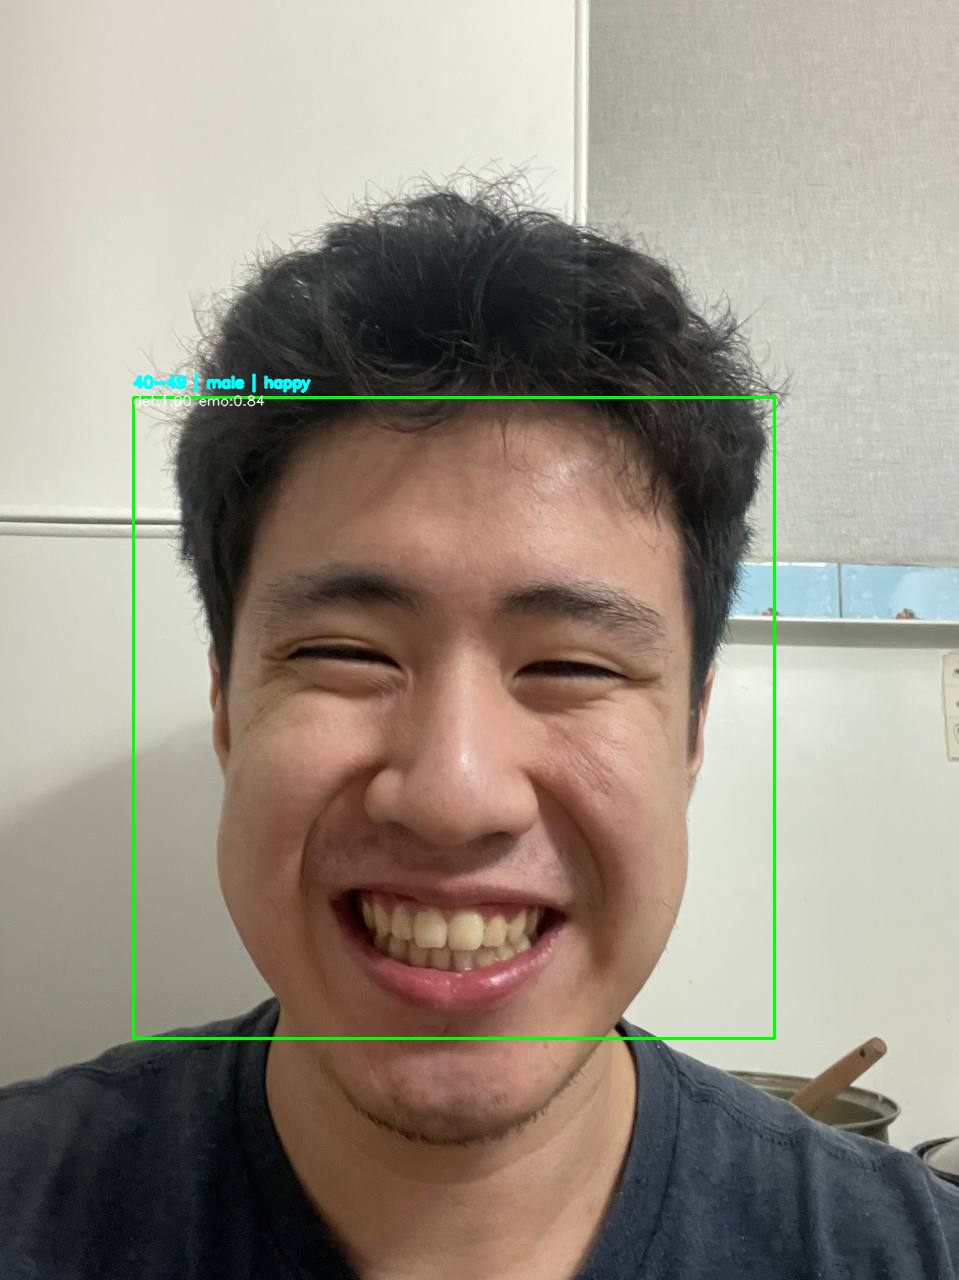

In [16]:
from pathlib import Path
import cv2
import tensorflow as tf
from IPython.display import display
from PIL import Image

from src.infer import annotate_image, detect_faces_bgr, load_detector, predict_face


LOCAL_IMAGE_PATH = r"C:\Users\Sarah\Desktop\projects\facerecogn\data\make.jpg"


if "age_gender_model" not in globals() or "emotion_model" not in globals():
    AG_BEST_PATH = Path(r"C:\Users\Sarah\Desktop\projects\facerecogn\artifacts\checkpoints\age_gender\age_gender_best.keras")
    EMO_BEST_PATH = Path(r"C:\Users\Sarah\Desktop\projects\facerecogn\artifacts\checkpoints\emotion\emotion_best.keras")
    if not AG_BEST_PATH.exists() or not EMO_BEST_PATH.exists():
        raise FileNotFoundError("Не найдены чекпоинты моделей в artifacts/checkpoints")
    age_gender_model = tf.keras.models.load_model(AG_BEST_PATH)
    emotion_model = tf.keras.models.load_model(EMO_BEST_PATH)

if "detector" not in globals():
    detector = load_detector()

image_path = Path(LOCAL_IMAGE_PATH)
if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

frame = cv2.imread(str(image_path))
if frame is None:
    raise ValueError(f"Cannot read image: {image_path}")

boxes = detect_faces_bgr(frame, detector)
if not boxes:
    print("No faces detected.")
    display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
else:
    preds = []
    for box in boxes:
        crop = frame[box.y1:box.y2, box.x1:box.x2]
        if crop.size == 0:
            continue
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        pred = predict_face(crop_rgb, age_gender_model, emotion_model)
        preds.append((box, pred))

    out = annotate_image(frame, preds)
    display(Image.fromarray(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)))


## 12. Demo: Video Upload + Overlay

Upload a video file (`.mp4` recommended), run frame-by-frame analysis, and get an annotated output video.

In [17]:
from IPython.display import HTML
from base64 import b64encode

LOCAL_VIDEO_PATH = "data/video.mp4"


if not LOCAL_VIDEO_PATH:
    raise ValueError('Set LOCAL_VIDEO_PATH for local runtime before running this cell.')
input_video = Path(LOCAL_VIDEO_PATH)
if not input_video.exists():
    raise FileNotFoundError(f'Video not found: {input_video}')
output_video = ARTIFACT_ROOT / 'inference' / f'{input_video.stem}_annotated.mp4'
output_video.parent.mkdir(parents=True, exist_ok=True)

result_path = run_video_inference(
    video_path=str(input_video),
    out_path=str(output_video),
    detector=detector,
    ag_model=age_gender_model,
    emo_model=emotion_model,
)

print('Annotated video saved to:', result_path)

if IS_COLAB:
    mp4 = open(result_path, 'rb').read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
    HTML(f'<video width=700 controls><source src="{data_url}" type="video/mp4"></video>')

Annotated video saved to: c:\Users\Sarah\Desktop\projects\facerecogn\artifacts\inference\video_annotated.mp4


## 13. Error Analysis

This section inspects common failures and helps guide model improvements.

Emotion misclassified samples: 1408


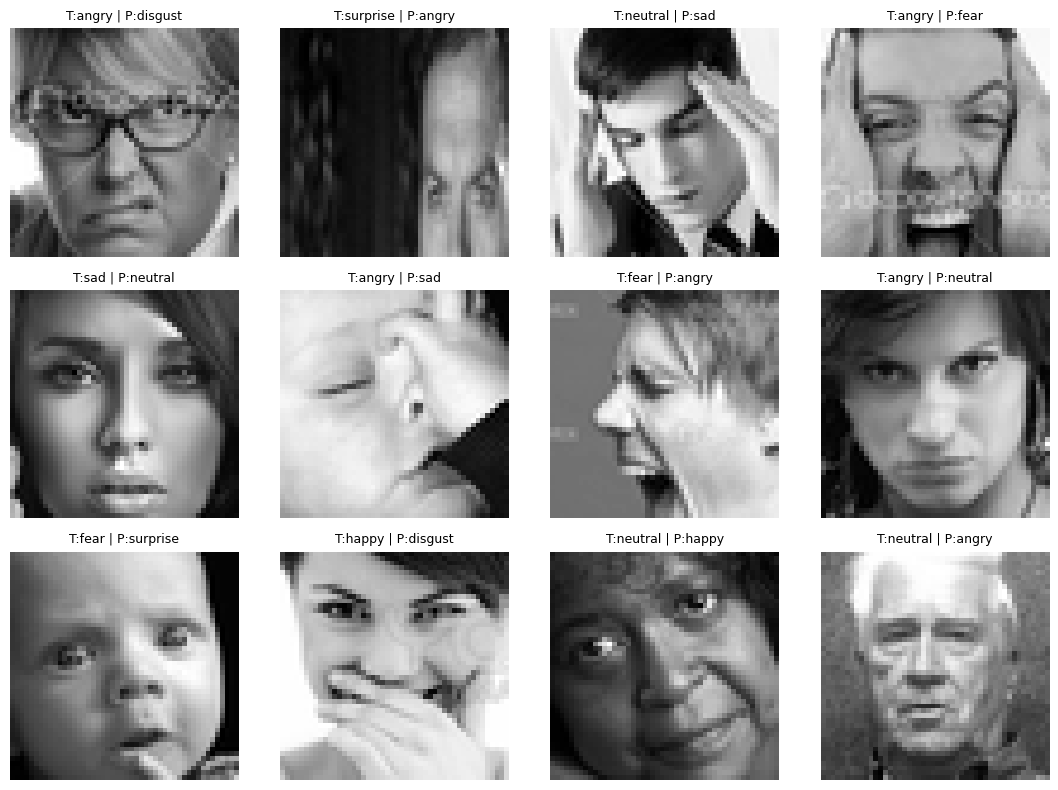

In [18]:
# Emotion misclassifications (test split)
import numpy as np


# RUN_MODE = globals().get("RUN_MODE", "train")
RUN_MODE = "train"
if RUN_MODE != 'train':
    print("Skipped in quick-infer mode.")
elif ("emo_results" not in globals()) or (emo_results is None):
    print("emo_results не посчитан. Сначала запусти ячейку Evaluation (раздел 9).")
else:
    wrong_idx = np.where(emo_results['y_true'] != emo_results['y_pred'])[0]
    print('Emotion misclassified samples:', len(wrong_idx))

    preview_n = min(12, len(wrong_idx))
    if preview_n > 0:
        subset = fer_test_df.iloc[wrong_idx[:preview_n]].copy().reset_index(drop=True)
        imgs, ttl = [], []
        for i in range(len(subset)):
            arr = np.fromstring(subset.loc[i, 'pixels'], sep=' ', dtype=np.uint8)
            if arr.size != 48 * 48:
                continue
            img = arr.reshape(48, 48)
            imgs.append(img)
            y_t = EMOTION_LABELS[int(emo_results['y_true'][wrong_idx[i]])]
            y_p = EMOTION_LABELS[int(emo_results['y_pred'][wrong_idx[i]])]
            ttl.append(f'T:{y_t} | P:{y_p}')

        if imgs:
            show_image_grid(np.array(imgs), titles=ttl, ncols=4, figsize=(11, 8))

In [19]:
# Top confusions for age groups
if RUN_MODE != 'train':
    print('Skipped confusion deep-dive in quick-infer mode.')
else:
    age_cm = ag_results['age_confusion_matrix'].copy()
    np.fill_diagonal(age_cm, 0)
    flat_idx = np.argsort(age_cm, axis=None)[::-1]
    print('Top age-group confusions:')
    shown = 0
    for idx in flat_idx:
        r, c = np.unravel_index(idx, age_cm.shape)
        if age_cm[r, c] == 0:
            break
        print(f'{AGE_GROUP_LABELS[r]} -> {AGE_GROUP_LABELS[c]}: {age_cm[r, c]}')
        shown += 1
        if shown == 5:
            break

Top age-group confusions:
30-39 -> 20-29: 345
20-29 -> 30-39: 141
40-49 -> 30-39: 108
40-49 -> 50-59: 92
10-19 -> 20-29: 78


## 14. Reproducibility and Re-run Guide

- Keep `SEED=42` fixed for consistent splits and initialization.
- Save artifacts in Drive under `face_analysis_artifacts`.
- For later sessions set `RUN_MODE='quick-infer'` and load checkpoints.

In [20]:
import platform

print('Python:', platform.python_version())
print('TensorFlow:', tf.__version__)
print('NumPy:', np.__version__)
print('Random seed:', SEED)
print('Checkpoint root:', CHECKPOINT_ROOT)
print('Age/Gender checkpoint exists:', AG_BEST_PATH.exists())
print('Emotion checkpoint exists:', EMO_BEST_PATH.exists())

Python: 3.11.9
TensorFlow: 2.21.0
NumPy: 2.4.3
Random seed: 42
Checkpoint root: c:\Users\Sarah\Desktop\projects\facerecogn\artifacts\checkpoints
Age/Gender checkpoint exists: True
Emotion checkpoint exists: True
